In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts images to PyTorch tensors (0 to 1 scale)
    # CIFAR-10 is RGB (3 channels). This normalizes each channel to a range of [-1, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:01<00:00, 101MB/s]


In [5]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

eval_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

cifar10_classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} testing images.")

Loaded 50000 training images and 10000 testing images.


In [6]:
# MLP Classifier

class MLP(nn.Module):
    """
    MLP composed of two fully connected layers.
     - First layer takes pixel values and maps them to a hidden dimension
     - Nonlinear activation
     - Second layer maps from hidden dimension to number of classes, predicting a score for each of the classes
    """
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        """ Model initalizer """
        super().__init__()
        self.layers = nn.Sequential(
                nn.Linear(in_features=input_dim, out_features=hidden_dim),
                nn.ReLU(),
                nn.Linear(in_features=hidden_dim, out_features=output_dim)
            )

    def forward(self, x):
        """ Forward pass through the model"""
        assert len(x.shape) == 2, f"ERROR! Shape of input must be 2D (b_size, dim)"
        pred = self.layers(x)
        return pred


def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params

NUM_EPOCHS = 10
LR = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp = MLP(input_dim=3072, hidden_dim=512, output_dim=10)
mlp = mlp.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)


Epoch 1 Train: 100%|██████████| 782/782 [00:23<00:00, 33.06it/s, loss=1.21051]


Epoch 1 Summary | Train Loss: 1.6253 | Eval Loss: 1.4917


Epoch 2 Train: 100%|██████████| 782/782 [00:23<00:00, 33.60it/s, loss=1.33393]


Epoch 2 Summary | Train Loss: 1.4222 | Eval Loss: 1.4277


Epoch 3 Train: 100%|██████████| 782/782 [00:27<00:00, 28.49it/s, loss=1.06147]


...

Epoch 8 Summary | Train Loss: 1.0112 | Eval Loss: 1.3590


Epoch 9 Train: 100%|██████████| 782/782 [00:24<00:00, 31.82it/s, loss=1.05447]


Epoch 9 Summary | Train Loss: 0.9568 | Eval Loss: 1.3658


Epoch 10 Train: 100%|██████████| 782/782 [00:24<00:00, 31.87it/s, loss=1.41759]


Epoch 10 Summary | Train Loss: 0.9088 | Eval Loss: 1.3767


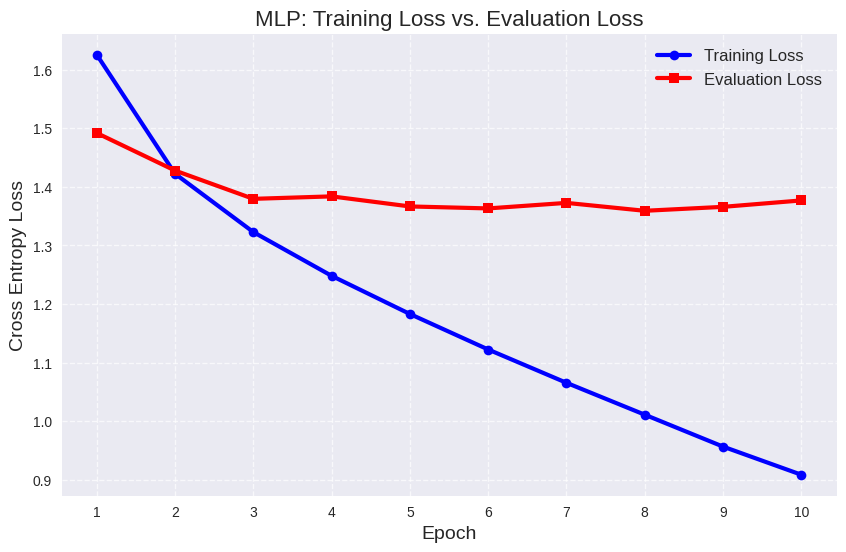

In [7]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

# Lists to track average loss per epoch
train_loss_list = []
eval_loss_list = []

for epoch in range(NUM_EPOCHS):

    mlp.train() # Set MLP to training mode
    running_train_loss = 0.0

    progress_bar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1} Train")
    for i, (imgs, labels) in enumerate(progress_bar):
        # Move to GPU
        imgs, labels = imgs.to(device), labels.to(device)

        # Flatten images for MLP: (Batch, 3, 32, 32) -> (Batch, 3072)
        flattened_imgs = imgs.flatten(start_dim=1)

        # Forward pass
        preds = mlp(flattened_imgs)

        # Compute error
        loss = criterion(preds, labels)
        running_train_loss += loss.item()

        # Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar every 10 batches
        if i % 10 == 0 or i == len(train_loader) - 1:
            progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    # Calculate average training loss for this epoch
    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE
    # ==========================================
    mlp.eval() # Set MLP to evaluation mode
    running_eval_loss = 0.0

    with torch.no_grad(): # Disable gradient tracking
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # FLATTEN IMAGES FOR EVALUATION TOO!
            flattened_imgs = imgs.flatten(start_dim=1)

            # Forward pass
            preds = mlp(flattened_imgs)

            # Compute evaluation error
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    # Calculate average evaluation loss for this epoch
    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    # Print the summary at the end of the epoch
    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

# ==========================================
# 3. PLOTTING THE LOSS
# ==========================================
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

# X-axis will be Epoch 1, 2, 3, etc.
epochs_range = range(1, NUM_EPOCHS + 1)

plt.plot(epochs_range, train_loss_list, label='Training Loss', color='blue', linewidth=3, marker='o')
plt.plot(epochs_range, eval_loss_list, label='Evaluation Loss', color='red', linewidth=3, marker='s')

plt.title('MLP: Training Loss vs. Evaluation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Cross Entropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs_range)

plt.show()

In [8]:
# MLP Eval

n_correct = 0

with torch.no_grad():
    progress_bar = tqdm(enumerate(eval_loader), total=len(eval_loader))
    for i, (imgs, labels) in progress_bar:
        #everything needs to be on the same device
        imgs = imgs.to(device)
        labels = labels.to(device)

        # forward pass
        flattened_imgs = imgs.flatten(start_dim=1)
        preds = mlp(flattened_imgs)

        pred_labels = torch.argmax(torch.softmax(preds, dim=-1), dim=-1)
        cur_correct = len(torch.where(pred_labels == labels)[0])
        n_correct = n_correct + cur_correct

accuracy = n_correct / len(test_dataset) * 100
print(f"Test accuracy: {round(accuracy,2)}%")

100%|██████████| 157/157 [00:03<00:00, 41.83it/s]

Test accuracy: 54.32%


In [9]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    """
    Varation of LeNet: a simple CNN model
    for CIFAR-10 image classification (32x32 RGB)
    """
    def __init__(self):
        """ Model initializer """
        super().__init__()

        # layer 1
        # Input: (3, 32, 32)
        conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
        # Output after conv1: (16, 28, 28)

        relu1 = nn.ReLU()
        maxpool1 = nn.MaxPool2d(kernel_size=2)
        # Output after maxpool1: (16, 14, 14)

        self.layer1 = nn.Sequential(
                conv1, relu1, maxpool1
            )

        # layer 2
        # Input: (16, 14, 14)
        conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        # Output after conv2: (32, 10, 10)

        relu2 = nn.ReLU()
        maxpool2 = nn.MaxPool2d(kernel_size=2)
        # Output after maxpool2: (32, 5, 5)

        self.layer2 = nn.Sequential(
                conv2, relu2, maxpool2
            )

        in_dim = 32 * 5 * 5
        self.fc = nn.Linear(in_features=in_dim, out_features=10)

    def forward(self, x):
        """ Forward pass """
        cur_b_size = x.shape[0]
        out1 = self.layer1(x)
        out2 = self.layer2(out1)     # Shape: (B, 32, 5, 5)
        out2_flat = out2.view(cur_b_size, -1) # Flattens to (B, 800)
        y = self.fc(out2_flat)
        return y

def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params

LR = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = CNN()
cnn = cnn.to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=cnn.parameters(), lr=LR)

In [10]:
# Lists to keep track of our average loss per epoch
train_loss_list = []
eval_loss_list = []

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # 1. TRAINING PHASE
    # ==========================================
    cnn.train()
    running_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train")
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = cnn(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Add up the loss for this batch
        running_train_loss += loss.item()

    # Calculate average training loss for this epoch
    # (Total loss divided by the number of batches)
    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE
    # ==========================================
    cnn.eval()
    running_eval_loss = 0.0

    with torch.no_grad():
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Forward pass
            preds = cnn(imgs)

            # Calculate Evaluation Loss
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    # Calculate average evaluation loss for this epoch
    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    # Print the summary
    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

Epoch 1 Train: 100%|██████████| 782/782 [00:33<00:00, 23.14it/s]


Epoch 1 Summary | Train Loss: 1.6923 | Eval Loss: 1.4647


Epoch 2 Train: 100%|██████████| 782/782 [00:33<00:00, 23.14it/s]


Epoch 2 Summary | Train Loss: 1.3936 | Eval Loss: 1.3219


Epoch 3 Train: 100%|██████████| 782/782 [00:34<00:00, 22.98it/s]


...

Epoch 8 Summary | Train Loss: 1.0384 | Eval Loss: 1.0683


Epoch 9 Train: 100%|██████████| 782/782 [00:33<00:00, 23.21it/s]


Epoch 9 Summary | Train Loss: 1.0117 | Eval Loss: 1.0504


Epoch 10 Train: 100%|██████████| 782/782 [00:35<00:00, 22.27it/s]


Epoch 10 Summary | Train Loss: 0.9893 | Eval Loss: 1.0356


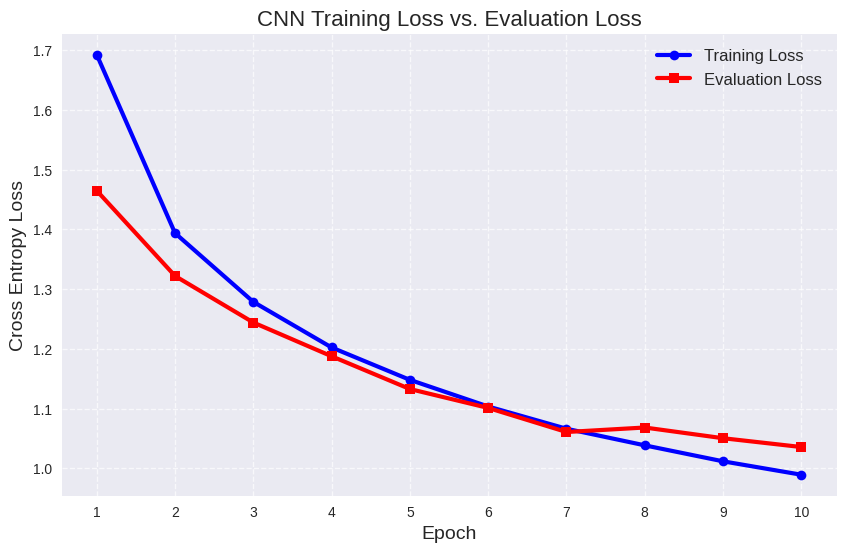

In [11]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

epochs_range = range(1, NUM_EPOCHS + 1)

# Plot both loss lines
plt.plot(epochs_range, train_loss_list, label='Training Loss', color='blue', linewidth=3, marker='o')
plt.plot(epochs_range, eval_loss_list, label='Evaluation Loss', color='red', linewidth=3, marker='s')

plt.title('CNN Training Loss vs. Evaluation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Cross Entropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs_range)

plt.show()

In [12]:
# Simple CNN Eval

n_correct = 0

with torch.no_grad():
    progress_bar = tqdm(enumerate(eval_loader), total=len(eval_loader))
    for i, (imgs, labels) in progress_bar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # forward pass
        preds = cnn(imgs)

        pred_labels = torch.argmax(torch.softmax(preds, dim=-1), dim=-1)
        cur_correct = len(torch.where(pred_labels == labels)[0])
        n_correct = n_correct + cur_correct

cnn_accuracy = n_correct / len(test_dataset) * 100
print(f"Test accuracy: {round(cnn_accuracy,2)}%")

100%|██████████| 157/157 [00:04<00:00, 39.14it/s]

Test accuracy: 64.1%


Gathering MLP predictions...
Gathering CNN predictions...


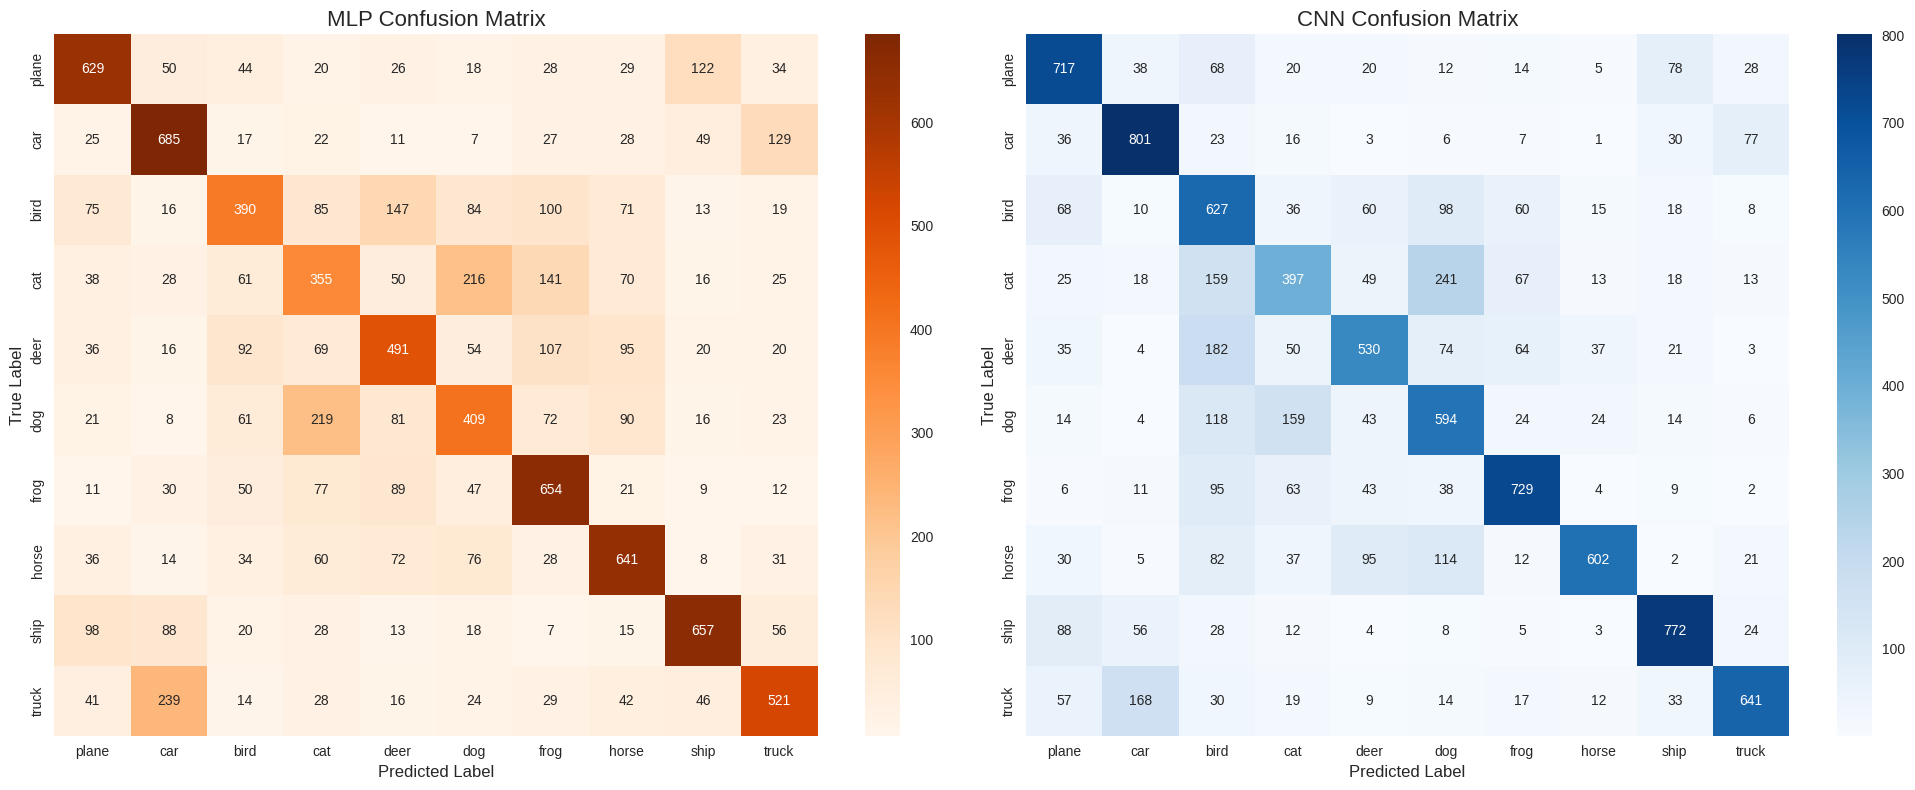

In [13]:
# Models confusion matrix


import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

@torch.no_grad()  # Disable gradients for evaluation
def get_all_predictions(model, dataloader, flatten_input=False):
    model.eval()

    all_preds = []
    all_true_labels = []

    for imgs, labels in dataloader:
        imgs = imgs.to(device)

        if flatten_input:
            imgs = imgs.flatten(start_dim=1)

        raw_scores = model(imgs)

        preds = torch.argmax(raw_scores, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.numpy())

    return all_true_labels, all_preds

print("Gathering MLP predictions...")
mlp_true, mlp_preds = get_all_predictions(mlp, eval_loader, flatten_input=True)

print("Gathering CNN predictions...")
cnn_true, cnn_preds = get_all_predictions(cnn, eval_loader, flatten_input=False)


# 3. Helper function to plot the matrices side-by-side
def plot_both_confusion_matrices(true_labels, mlp_p, cnn_p, classes):
    # Calculate the mathematical matrices
    cm_mlp = confusion_matrix(true_labels, mlp_p)
    cm_cnn = confusion_matrix(true_labels, cnn_p)

    # Set up the plot (1 row, 2 columns)
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    # Plot MLP Matrix
    sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
                xticklabels=classes, yticklabels=classes)
    ax[0].set_title('MLP Confusion Matrix', fontsize=16)
    ax[0].set_xlabel('Predicted Label', fontsize=12)
    ax[0].set_ylabel('True Label', fontsize=12)

    # Plot CNN Matrix
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax[1],
                xticklabels=classes, yticklabels=classes)
    ax[1].set_title('CNN Confusion Matrix', fontsize=16)
    ax[1].set_xlabel('Predicted Label', fontsize=12)
    ax[1].set_ylabel('True Label', fontsize=12)

    plt.tight_layout()
    plt.show()

# 4. Draw the plots!
plot_both_confusion_matrices(cnn_true, mlp_preds, cnn_preds, cifar10_classes)

CNN is performing much better than the MLP Classifier. MLP Classifier has 53.74% accuracy while the Simple CNN has 64.18%. The dog is the worst performing in the MLP and CNN, both mistaken it for a cat. At 10 epochs, there has been a big gap between training loss and eval loss for both CNN and MLP models, which indicated overfitting in CNN. After lowering epochs to 10, CNN model showed great improvments, however MLP had the same problem.

--- MLP Predictions ---


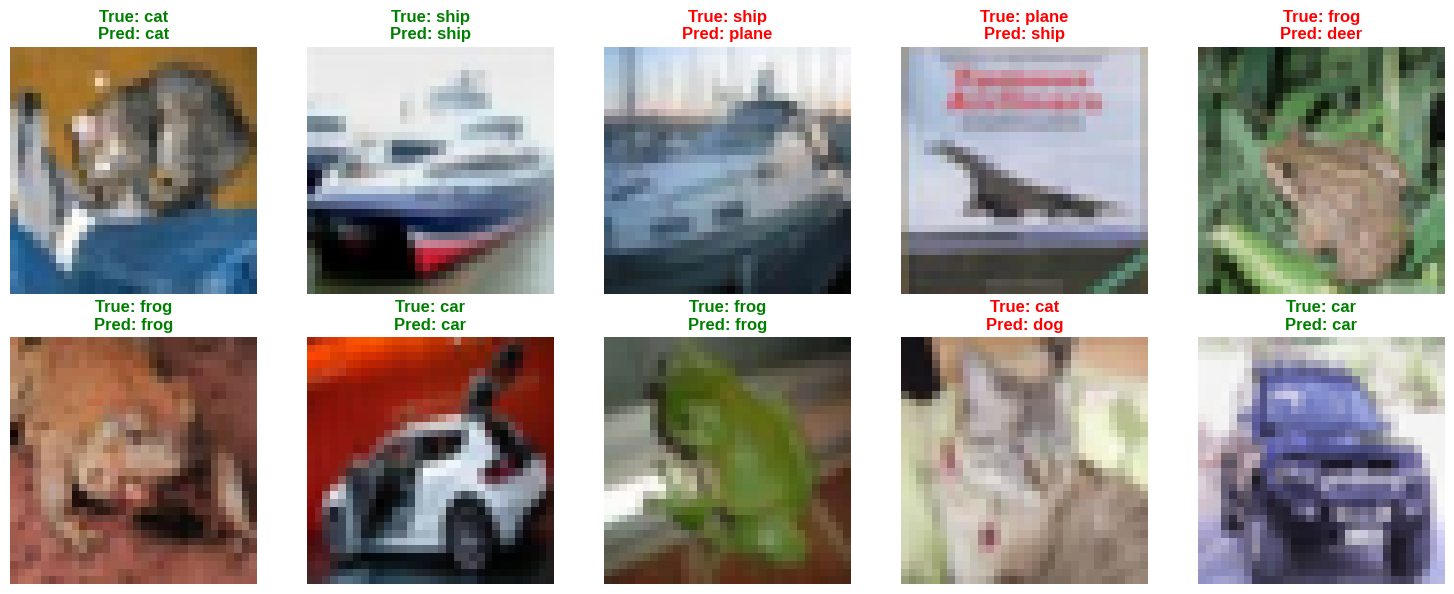


--- CNN Predictions ---


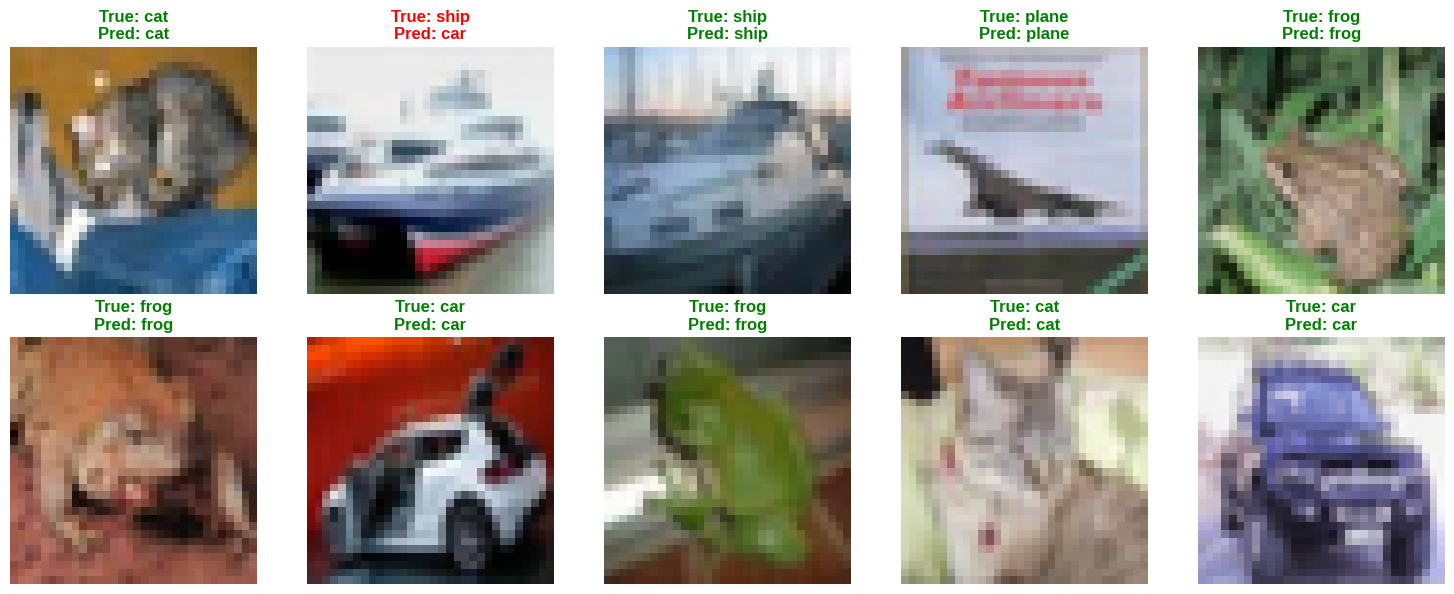

In [14]:
# Plotting eval images

def imshow(img):
    img = img / 2 + 0.5     # Un-normalize: reverses the (x - 0.5) / 0.5 math
    npimg = img.numpy()
    # PyTorch is (Channels, Height, Width). Matplotlib expects (Height, Width, Channels)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# 2. Main visualization function
def visualize_predictions(model, dataloader, classes, is_mlp=False, num_images=10):
    model.eval() # Set to evaluation mode

    # Grab exactly one batch of data
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    # Move to GPU for prediction
    images_dev = images.to(device)

    # Flatten if it's the MLP
    if is_mlp:
        images_dev = images_dev.flatten(start_dim=1)

    # Get predictions
    with torch.no_grad():
        outputs = model(images_dev)
        preds = torch.argmax(outputs, dim=1)

    # Move predictions back to CPU for text labels
    preds = preds.cpu()

    fig = plt.figure(figsize=(15, 6))
    for idx in range(num_images):
        ax = fig.add_subplot(2, num_images // 2, idx + 1, xticks=[], yticks=[])
        imshow(images[idx])

        true_label = classes[labels[idx]]
        pred_label = classes[preds[idx]]

        title_color = "green" if true_label == pred_label else "red"
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- Run the Visualizations ---
print("--- MLP Predictions ---")
visualize_predictions(mlp, eval_loader, cifar10_classes, is_mlp=True)

print("\n--- CNN Predictions ---")
visualize_predictions(cnn, eval_loader, cifar10_classes, is_mlp=False)

Although CNN performes much better than MLP, both aren't making "understandable" mistakes. For instance MLP predicted a dog for a car, and CNN predicted a cat for a car. Semantically this does not make any sense. My assumption is the CNN does not have enough layers, which means it does not have enough deep info regarding the photos. For the MLP it fundementally does not understand images, the flattenning approach destroys any spatial relations between the pixels.

In [15]:
# MLP model with droupout

import torch.nn as nn

class MLP_WITH_DROPOUT(nn.Module):
    """
    MLP composed of two fully connected layers WITH DROPOUT.
    """
    def __init__(self, input_dim=3072, hidden_dim=512, output_dim=10, dropout_rate=0.5):
        super().__init__()

        self.layers = nn.Sequential(
                # 1. Hidden Layer
                nn.Linear(in_features=input_dim, out_features=hidden_dim),

                # 2. Activation
                nn.ReLU(),

                # 3. DROPOUT LAYER (Turns off a percentage of neurons)
                nn.Dropout(p=dropout_rate),

                # 4. Final Output Layer
                nn.Linear(in_features=hidden_dim, out_features=output_dim)
            )

    def forward(self, x):
        """ Forward pass through the model"""
        assert len(x.shape) == 2, f"ERROR! Shape of input must be 2D (b_size, dim)"
        pred = self.layers(x)
        return pred

mlp_dropout = MLP_WITH_DROPOUT(input_dim=3072, hidden_dim=512, output_dim=10, dropout_rate=0.5)
mlp_dropout = mlp_dropout.to(device)

optimizer = torch.optim.Adam(mlp_dropout.parameters(), lr=LR)

Epoch 1 Train: 100%|██████████| 782/782 [00:25<00:00, 30.78it/s, loss=1.63164]


Epoch 1 Summary | Train Loss: 1.7341 | Eval Loss: 1.5281


Epoch 2 Train: 100%|██████████| 782/782 [00:25<00:00, 30.87it/s, loss=1.50357]


Epoch 2 Summary | Train Loss: 1.5856 | Eval Loss: 1.4763


Epoch 3 Train: 100%|██████████| 782/782 [00:25<00:00, 31.07it/s, loss=1.76415]


...

Epoch 8 Summary | Train Loss: 1.3654 | Eval Loss: 1.3525


Epoch 9 Train: 100%|██████████| 782/782 [00:25<00:00, 31.17it/s, loss=1.41468]


Epoch 9 Summary | Train Loss: 1.3466 | Eval Loss: 1.3428


Epoch 10 Train: 100%|██████████| 782/782 [00:25<00:00, 31.12it/s, loss=1.09245]


Epoch 10 Summary | Train Loss: 1.3259 | Eval Loss: 1.3490


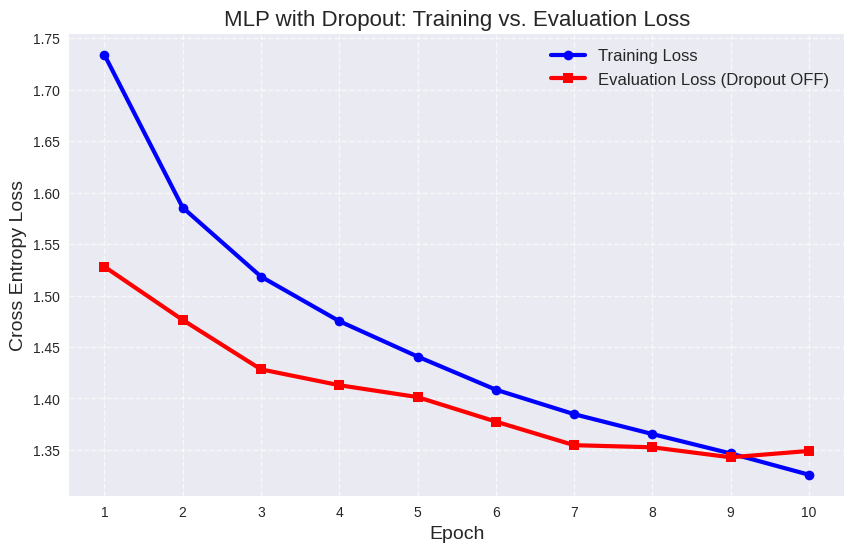

In [16]:
train_loss_list = []
eval_loss_list = []

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # 1. TRAINING PHASE
    # ==========================================
    mlp_dropout.train() # CRITICAL: Turns Dropout ON
    running_train_loss = 0.0

    progress_bar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1} Train")
    for i, (imgs, labels) in enumerate(progress_bar):
        # Move to GPU
        imgs, labels = imgs.to(device), labels.to(device)

        # Flatten images for MLP: (Batch, 3, 32, 32) -> (Batch, 3072)
        flattened_imgs = imgs.flatten(start_dim=1)

        # Forward pass
        preds = mlp_dropout(flattened_imgs)

        # Compute error
        loss = criterion(preds, labels)
        running_train_loss += loss.item()

        # Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar
        if i % 10 == 0 or i == len(train_loader) - 1:
            progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    # Calculate average training loss for this epoch
    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE
    # ==========================================
    mlp_dropout.eval() # CRITICAL: Turns Dropout OFF!
    running_eval_loss = 0.0

    with torch.no_grad(): # Disable gradient tracking
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Flatten images for evaluation too
            flattened_imgs = imgs.flatten(start_dim=1)

            # Forward pass
            preds = mlp_dropout(flattened_imgs)

            # Compute evaluation error
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    # Calculate average evaluation loss for this epoch
    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    # Print the summary at the end of the epoch
    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

# ==========================================
# 3. PLOTTING THE LOSS
# ==========================================
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

epochs_range = range(1, NUM_EPOCHS + 1)

plt.plot(epochs_range, train_loss_list, label='Training Loss', color='blue', linewidth=3, marker='o')
plt.plot(epochs_range, eval_loss_list, label='Evaluation Loss (Dropout OFF)', color='red', linewidth=3, marker='s')

plt.title('MLP with Dropout: Training vs. Evaluation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Cross Entropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs_range)

plt.show()

After using dropout, MLP graph shows reasonable difference between train and eval results, which indicates overfitting has been reduced by alot.Although overfitting was cured, we accidently introduced underfitting. This means that the model is not able to fully understand the images patterns, and that dropout deprived it more. We could increase the epochs and reduce the p in dropout.

In [17]:
# CNN with dropout

import torch.nn as nn

class CNN_WITH_DROPOUT(nn.Module):
    """
    CNN model for CIFAR-10 image classification (32x32 RGB)
    WITH DROPOUT to prevent overfitting.
    """
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        # Layer 1: Convolutions
        self.layer1 = nn.Sequential(
                nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )

        # Layer 2: Convolutions
        self.layer2 = nn.Sequential(
                nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )

        # Fully Connected Classifier Block
        in_dim = 32 * 5 * 5  # 800 features

        self.classifier = nn.Sequential(
            # CRITICAL: We drop 50% of the flattened features before classification
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features=in_dim, out_features=10)
        )

    def forward(self, x):
        cur_b_size = x.shape[0]
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out2_flat = out2.view(cur_b_size, -1)

        # Pass the flattened data through the Dropout and Linear layer
        y = self.classifier(out2_flat)
        return y

cnn_dropout = CNN_WITH_DROPOUT(dropout_rate=0.5).to(device)
optimizer = torch.optim.Adam(params=cnn_dropout.parameters(), lr=LR)

In [18]:
train_loss_list = []
eval_loss_list = []

for epoch in range(NUM_EPOCHS):

    # ==========================================
    # 1. TRAINING PHASE (Dropout ON)
    # ==========================================
    cnn_dropout.train()
    running_train_loss = 0.0

    progress_bar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1} Train")
    for i, (imgs, labels) in enumerate(progress_bar):
        imgs, labels = imgs.to(device), labels.to(device)

        # Forward pass (NO manual flattening needed here!)
        preds = cnn_dropout(imgs)

        # Compute error
        loss = criterion(preds, labels)
        running_train_loss += loss.item()

        # Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar
        if i % 10 == 0 or i == len(train_loader) - 1:
            progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE (Dropout OFF)
    # ==========================================
    cnn_dropout.eval()
    running_eval_loss = 0.0

    with torch.no_grad():
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Forward pass
            preds = cnn_dropout(imgs)

            # Compute error
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

Epoch 1 Train: 100%|██████████| 782/782 [00:35<00:00, 21.79it/s, loss=1.91452]


Epoch 1 Summary | Train Loss: 1.7884 | Eval Loss: 1.5112


Epoch 2 Train: 100%|██████████| 782/782 [00:36<00:00, 21.68it/s, loss=1.51564]


Epoch 2 Summary | Train Loss: 1.4908 | Eval Loss: 1.3596


Epoch 3 Train: 100%|██████████| 782/782 [00:36<00:00, 21.62it/s, loss=0.99180]


...

Epoch 8 Summary | Train Loss: 1.1575 | Eval Loss: 1.0688


Epoch 9 Train: 100%|██████████| 782/782 [00:35<00:00, 21.76it/s, loss=1.02347]


Epoch 9 Summary | Train Loss: 1.1351 | Eval Loss: 1.0558


Epoch 10 Train: 100%|██████████| 782/782 [00:36<00:00, 21.68it/s, loss=1.03684]


Epoch 10 Summary | Train Loss: 1.1155 | Eval Loss: 1.0329


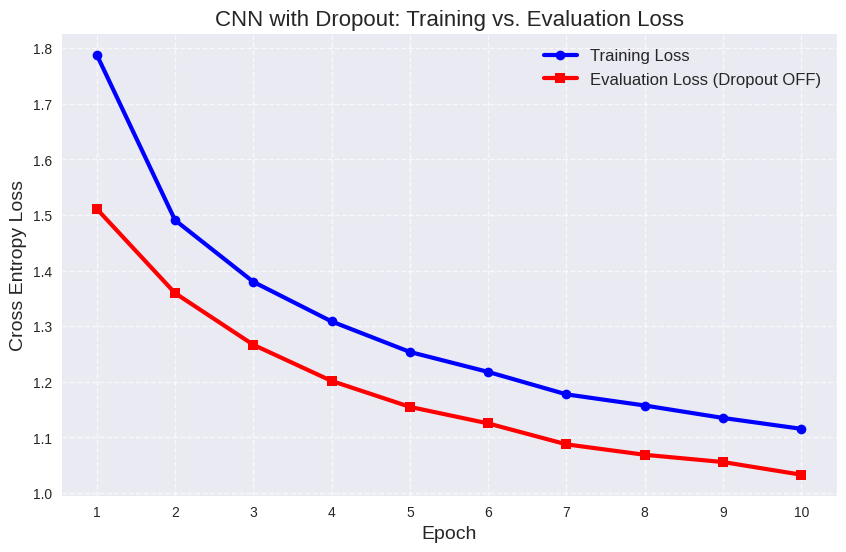

In [19]:
# ==========================================
# 3. PLOTTING THE LOSS
# ==========================================
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

epochs_range = range(1, NUM_EPOCHS + 1)

plt.plot(epochs_range, train_loss_list, label='Training Loss', color='blue', linewidth=3, marker='o')
plt.plot(epochs_range, eval_loss_list, label='Evaluation Loss (Dropout OFF)', color='red', linewidth=3, marker='s')

plt.title('CNN with Dropout: Training vs. Evaluation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Cross Entropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs_range)

plt.show()

Dropout in CNN does not appear to be improving its performance.

In [20]:
train_loss_list = []
eval_loss_list = []
NUM_EPOCHS_DROPOUT = 20

for epoch in range(NUM_EPOCHS_DROPOUT):

    # ==========================================
    # 1. TRAINING PHASE (Dropout ON)
    # ==========================================
    cnn_dropout.train()
    running_train_loss = 0.0

    progress_bar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1} Train")
    for i, (imgs, labels) in enumerate(progress_bar):
        imgs, labels = imgs.to(device), labels.to(device)

        # Forward pass (NO manual flattening needed here!)
        preds = cnn_dropout(imgs)

        # Compute error
        loss = criterion(preds, labels)
        running_train_loss += loss.item()

        # Backward pass & optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar
        if i % 10 == 0 or i == len(train_loader) - 1:
            progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE (Dropout OFF)
    # ==========================================
    cnn_dropout.eval()
    running_eval_loss = 0.0

    with torch.no_grad():
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            # Forward pass
            preds = cnn_dropout(imgs)

            # Compute error
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

Epoch 1 Train: 100%|██████████| 782/782 [00:36<00:00, 21.70it/s, loss=1.40595]


Epoch 1 Summary | Train Loss: 1.0990 | Eval Loss: 1.0131


Epoch 2 Train: 100%|██████████| 782/782 [00:36<00:00, 21.71it/s, loss=1.04789]


Epoch 2 Summary | Train Loss: 1.0776 | Eval Loss: 1.0050


Epoch 3 Train: 100%|██████████| 782/782 [00:35<00:00, 21.86it/s, loss=0.86276]


...

Epoch 18 Summary | Train Loss: 0.9427 | Eval Loss: 0.8793


Epoch 19 Train: 100%|██████████| 782/782 [00:36<00:00, 21.58it/s, loss=0.70064]


Epoch 19 Summary | Train Loss: 0.9370 | Eval Loss: 0.8744


Epoch 20 Train: 100%|██████████| 782/782 [00:36<00:00, 21.32it/s, loss=0.72946]


Epoch 20 Summary | Train Loss: 0.9321 | Eval Loss: 0.8763


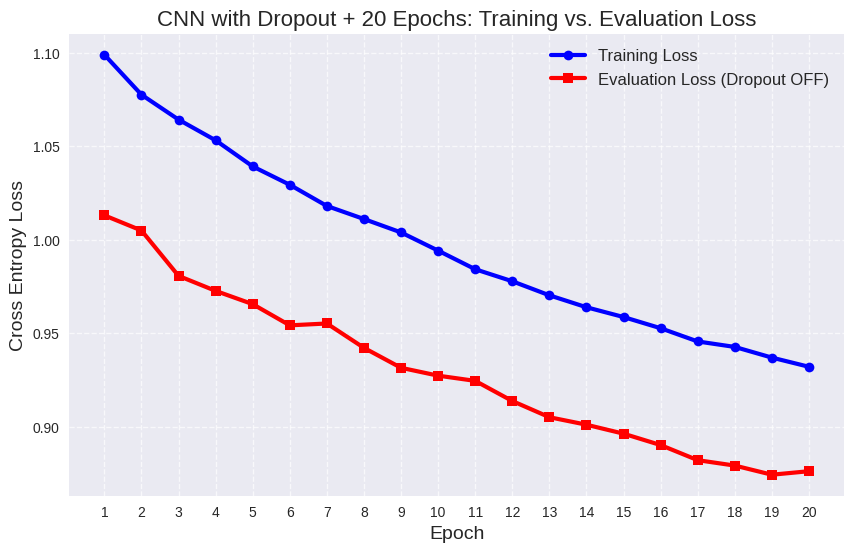

In [21]:
# ==========================================
# 3. PLOTTING THE LOSS
# ==========================================
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))

epochs_range = range(1, NUM_EPOCHS_DROPOUT + 1)

plt.plot(epochs_range, train_loss_list, label='Training Loss', color='blue', linewidth=3, marker='o')
plt.plot(epochs_range, eval_loss_list, label='Evaluation Loss (Dropout OFF)', color='red', linewidth=3, marker='s')

plt.title('CNN with Dropout + 20 Epochs: Training vs. Evaluation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Cross Entropy Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs_range)

plt.show()

After increasing epochs to 20, the model is performing much better, which makes sense since dropout mechanism forces model to take longer to learn. This is the best performance for the CNN model so far.

Eval loss is lower than training since we have dropout on, which means we are not using the full potential of the model during training, but turning it off during eval.

In [22]:

# Helper function to get predictions
@torch.no_grad()
def get_predictions(model, dataloader, flatten=False):
    model.eval()
    all_preds = []
    all_true = []

    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        if flatten:
            imgs = imgs.flatten(start_dim=1)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

    acc = accuracy_score(all_true, all_preds) * 100
    return all_true, all_preds, acc

print("Gathering predictions (this may take a few seconds)...")
# Get MLP predictions (requires flattening)
true_labels, mlp_preds, mlp_acc = get_predictions(mlp, eval_loader, flatten=True)
_, mlp_drop_preds, mlp_drop_acc = get_predictions(mlp_dropout, eval_loader, flatten=True)

# Get CNN predictions (no flattening)
_, cnn_preds, cnn_acc = get_predictions(cnn, eval_loader, flatten=False)
_, cnn_drop_preds, cnn_drop_acc = get_predictions(cnn_dropout, eval_loader, flatten=False)

print(f"MLP Accuracy:                 {mlp_acc:.2f}%")
print(f"MLP (with Dropout) Accuracy:  {mlp_drop_acc:.2f}%")
print(f"CNN Accuracy:                 {cnn_acc:.2f}%")
print(f"CNN (with Dropout) Accuracy:  {cnn_drop_acc:.2f}%")

Gathering predictions (this may take a few seconds)...
MLP Accuracy:                 54.32%
MLP (with Dropout) Accuracy:  53.20%
CNN Accuracy:                 64.10%
CNN (with Dropout) Accuracy:  69.73%


MLP with dropout performed worse than without. Acurracy on the other hand increased for CNN when adding the dropout and increasing epochs.

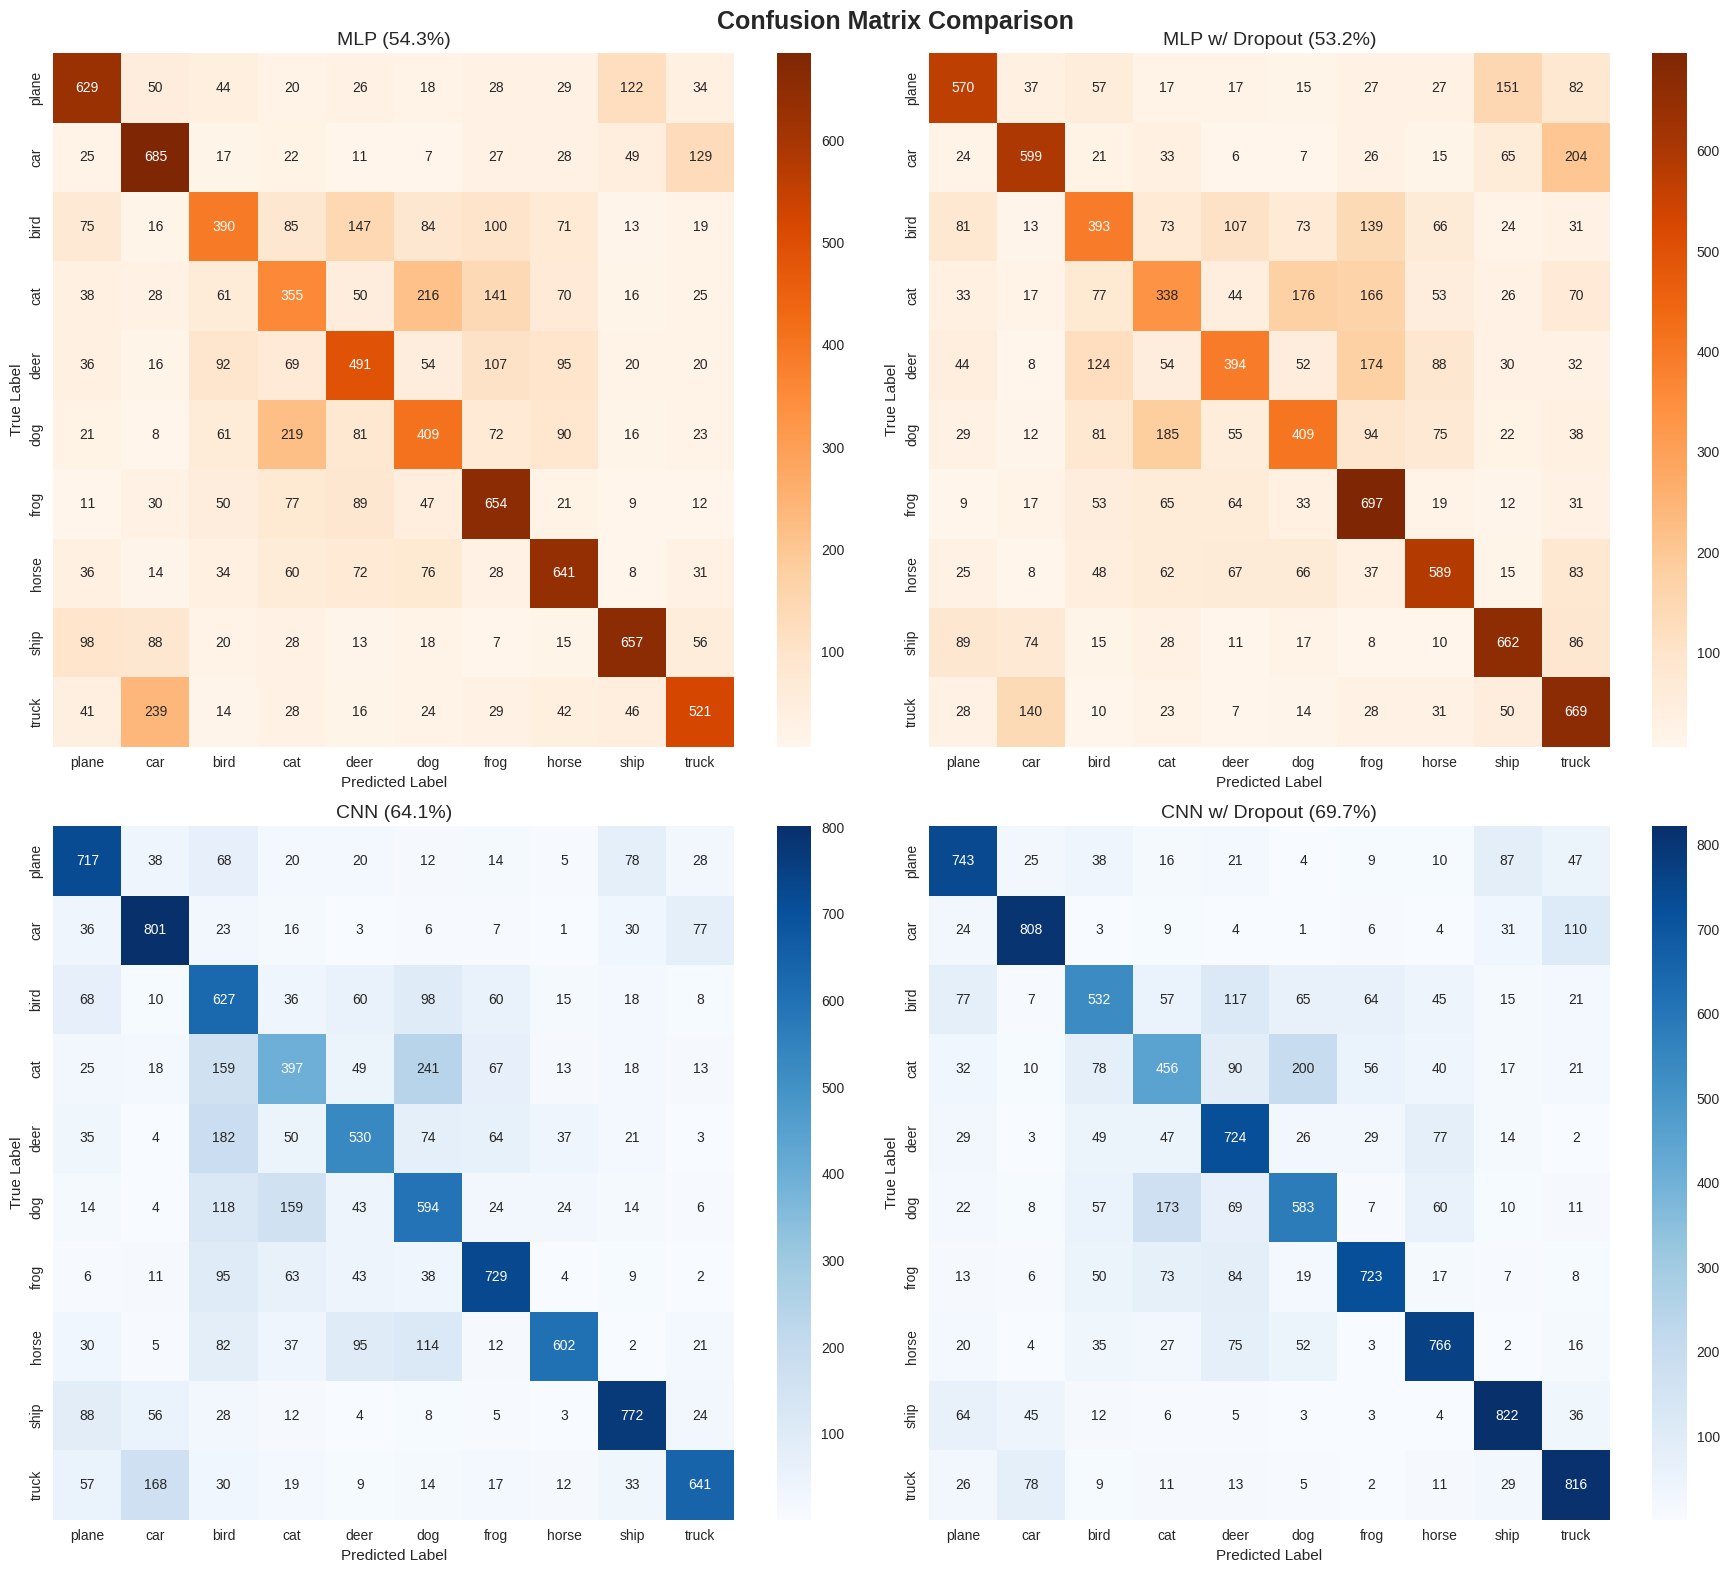

In [23]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Confusion Matrix Comparison', fontsize=18, fontweight='bold')

def plot_cm(ax, y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=cifar10_classes, yticklabels=cifar10_classes)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plot_cm(axes[0,0], true_labels, mlp_preds, f'MLP ({mlp_acc:.1f}%)', 'Oranges')
plot_cm(axes[0,1], true_labels, mlp_drop_preds, f'MLP w/ Dropout ({mlp_drop_acc:.1f}%)', 'Oranges')
plot_cm(axes[1,0], true_labels, cnn_preds, f'CNN ({cnn_acc:.1f}%)', 'Blues')
plot_cm(axes[1,1], true_labels, cnn_drop_preds, f'CNN w/ Dropout ({cnn_drop_acc:.1f}%)', 'Blues')

plt.tight_layout()
plt.show()

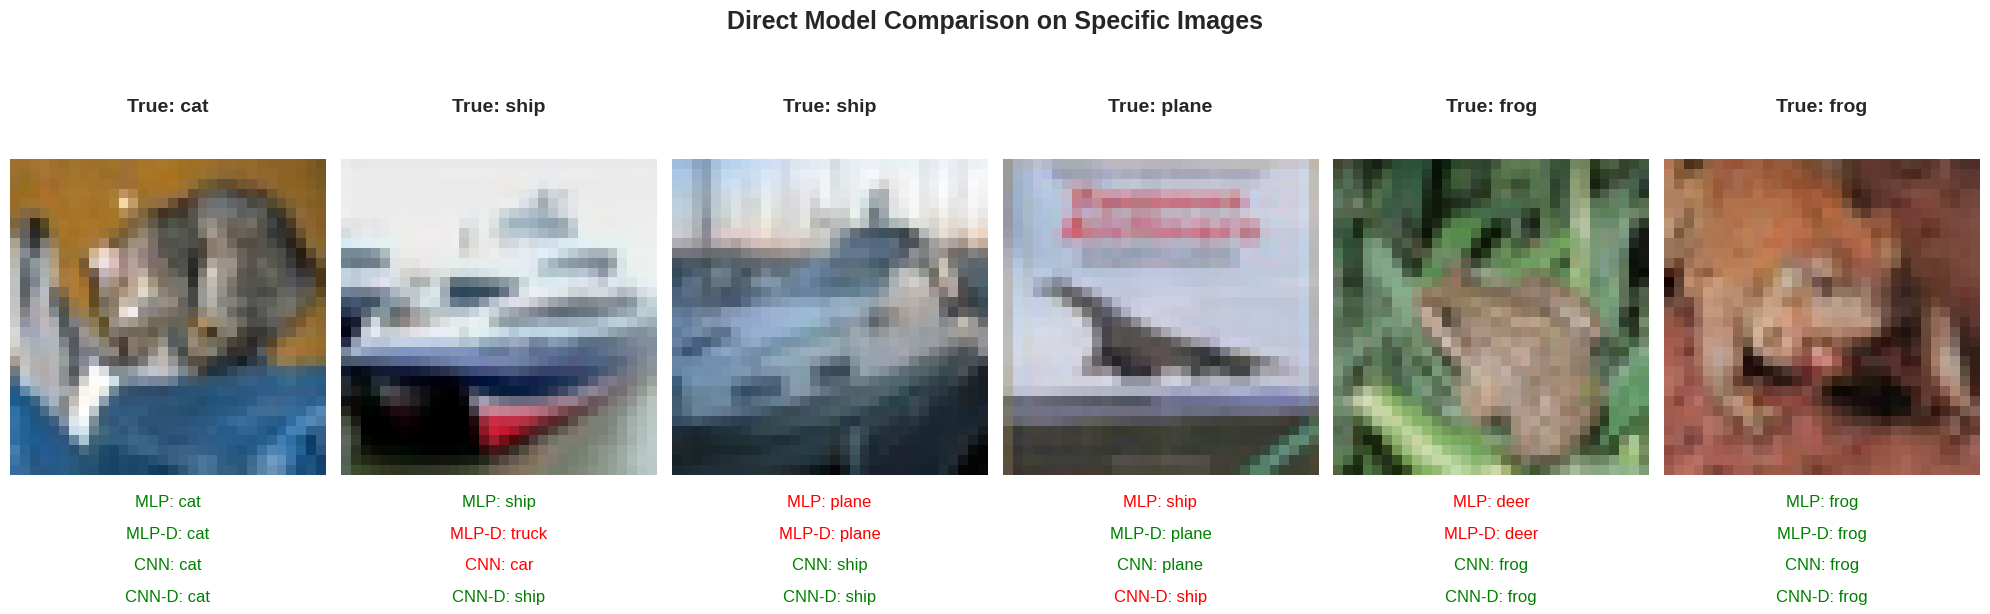

In [24]:
def unnormalize_and_plot(img, ax):
    img = img / 2 + 0.5  # unnormalize back to [0, 1]
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

# Grab one batch of evaluation images
dataiter = iter(eval_loader)
images, labels = next(dataiter)

num_images = 6
fig, axes = plt.subplots(1, num_images, figsize=(20, 6))
fig.suptitle('Direct Model Comparison on Specific Images', fontsize=18, fontweight='bold')

# Set models to evaluation mode
mlp.eval(); mlp_dropout.eval(); cnn.eval(); cnn_dropout.eval()

with torch.no_grad():
    imgs_gpu = images.to(device)
    flattened_imgs = imgs_gpu.flatten(start_dim=1)

    # Get predictions for this specific batch
    out_mlp = torch.argmax(mlp(flattened_imgs), dim=1).cpu()
    out_mlp_d = torch.argmax(mlp_dropout(flattened_imgs), dim=1).cpu()
    out_cnn = torch.argmax(cnn(imgs_gpu), dim=1).cpu()
    out_cnn_d = torch.argmax(cnn_dropout(imgs_gpu), dim=1).cpu()

for i in range(num_images):
    unnormalize_and_plot(images[i], axes[i])

    true_cls = cifar10_classes[labels[i]]
    p_mlp = cifar10_classes[out_mlp[i]]
    p_mlp_d = cifar10_classes[out_mlp_d[i]]
    p_cnn = cifar10_classes[out_cnn[i]]
    p_cnn_d = cifar10_classes[out_cnn_d[i]]

    # Text formatting (Green if correct, Red if wrong)
    t_mlp   = f"MLP: {p_mlp}"
    t_mlp_d = f"MLP-D: {p_mlp_d}"
    t_cnn   = f"CNN: {p_cnn}"
    t_cnn_d = f"CNN-D: {p_cnn_d}"

    title_text = f"True: {true_cls}\n\n"
    axes[i].set_title(title_text, fontweight='bold', fontsize=14)

    # Add colored text below the image
    axes[i].text(0.5, -0.1, t_mlp, color='green' if p_mlp==true_cls else 'red',
                 ha='center', transform=axes[i].transAxes, fontsize=12)
    axes[i].text(0.5, -0.2, t_mlp_d, color='green' if p_mlp_d==true_cls else 'red',
                 ha='center', transform=axes[i].transAxes, fontsize=12)
    axes[i].text(0.5, -0.3, t_cnn, color='green' if p_cnn==true_cls else 'red',
                 ha='center', transform=axes[i].transAxes, fontsize=12)
    axes[i].text(0.5, -0.4, t_cnn_d, color='green' if p_cnn_d==true_cls else 'red',
                 ha='center', transform=axes[i].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

Epoch 1 Train: 100%|██████████| 782/782 [00:36<00:00, 21.52it/s, loss=1.4381, lr=0.000500]


Epoch 1 Summary | Train Loss: 1.6682 | Eval Loss: 1.4348


Epoch 2 Train: 100%|██████████| 782/782 [00:36<00:00, 21.64it/s, loss=1.0737, lr=0.001000]


Epoch 2 Summary | Train Loss: 1.3548 | Eval Loss: 1.2365


Epoch 3 Train: 100%|██████████| 782/782 [00:35<00:00, 21.74it/s, loss=0.9563, lr=0.000950]


...

Epoch 23 Summary | Train Loss: 0.7723 | Eval Loss: 0.8135


Epoch 24 Train: 100%|██████████| 782/782 [00:36<00:00, 21.22it/s, loss=0.5547, lr=0.000324]


Epoch 24 Summary | Train Loss: 0.7631 | Eval Loss: 0.8237


Epoch 25 Train: 100%|██████████| 782/782 [00:37<00:00, 20.69it/s, loss=0.9915, lr=0.000307]


Epoch 25 Summary | Train Loss: 0.7586 | Eval Loss: 0.8060


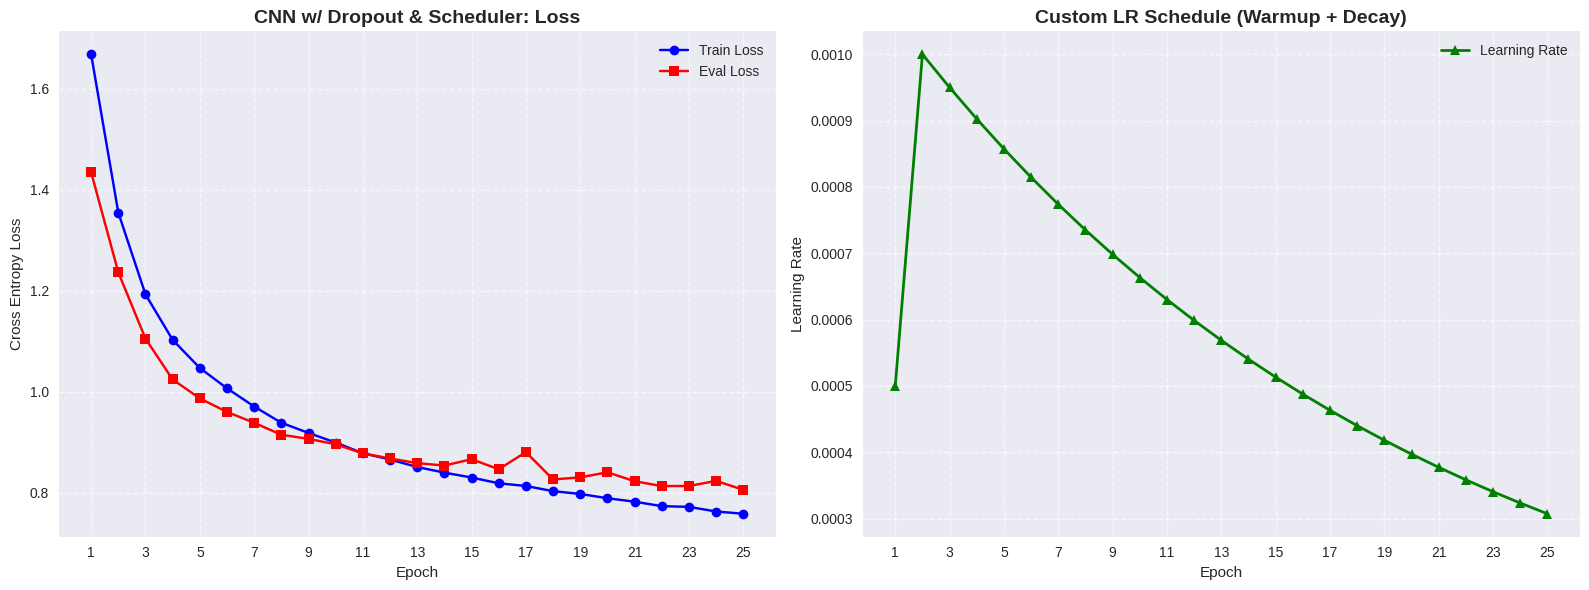

In [25]:
# custom learning rate warmup and learning rate scheduler

def custom_lr_scheduler(optimizer, epoch, base_lr=1e-3, warmup_epochs=2, gamma=0.95):
    """Linear warmup followed by exponential decay."""
    if epoch < warmup_epochs:
        lr = base_lr * ((epoch + 1) / warmup_epochs)
    else:
        decay_steps = epoch - warmup_epochs + 1
        lr = base_lr * (gamma ** decay_steps)

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

NUM_EPOCHS = 25
BASE_LR = 1e-3

cnn_dropout = CNN_WITH_DROPOUT(dropout_rate=0.25).to(device)
optimizer = torch.optim.Adam(cnn_dropout.parameters(), lr=BASE_LR)
criterion = nn.CrossEntropyLoss().to(device)

train_loss_list = []
eval_loss_list = []
lr_list = []

for epoch in range(NUM_EPOCHS):

    # Update Learning Rate
    current_lr = custom_lr_scheduler(optimizer, epoch, BASE_LR, warmup_epochs=2, gamma=0.95)
    lr_list.append(current_lr)

    # --- TRAINING PHASE ---
    cnn_dropout.train()
    running_train_loss = 0.0
    progress_bar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1} Train")

    for i, (imgs, labels) in enumerate(progress_bar):
        imgs, labels = imgs.to(device), labels.to(device)

        preds = cnn_dropout(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        if i % 10 == 0 or i == len(train_loader) - 1:
            progress_bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{current_lr:.6f}")

    epoch_train_loss = running_train_loss / len(train_loader)
    train_loss_list.append(epoch_train_loss)

    # --- EVALUATION PHASE ---
    cnn_dropout.eval()
    running_eval_loss = 0.0

    with torch.no_grad():
        for imgs, labels in eval_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = cnn_dropout(imgs)
            loss = criterion(preds, labels)
            running_eval_loss += loss.item()

    epoch_eval_loss = running_eval_loss / len(eval_loader)
    eval_loss_list.append(epoch_eval_loss)

    print(f"Epoch {epoch+1} Summary | Train Loss: {epoch_train_loss:.4f} | Eval Loss: {epoch_eval_loss:.4f}")

# ==========================================
# 5. PLOTTING RESULTS
# ==========================================
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, NUM_EPOCHS + 1)

# Plot 1: Loss
ax[0].plot(epochs_range, train_loss_list, label='Train Loss', color='blue', marker='o')
ax[0].plot(epochs_range, eval_loss_list, label='Eval Loss', color='red', marker='s')
ax[0].set_title('CNN w/ Dropout & Scheduler: Loss', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Cross Entropy Loss')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].set_xticks(epochs_range[::2]) # Prevent x-axis crowding

# Plot 2: Learning Rate
ax[1].plot(epochs_range, lr_list, label='Learning Rate', color='green', marker='^', linewidth=2)
ax[1].set_title('Custom LR Schedule (Warmup + Decay)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Learning Rate')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)
ax[1].set_xticks(epochs_range[::2])

plt.tight_layout()
plt.show()

Gathering predictions for final report...

FINAL MODEL PERFORMANCE REPORT
Accuracy:  72.20%
Precision: 72.30%
Recall:    72.20%


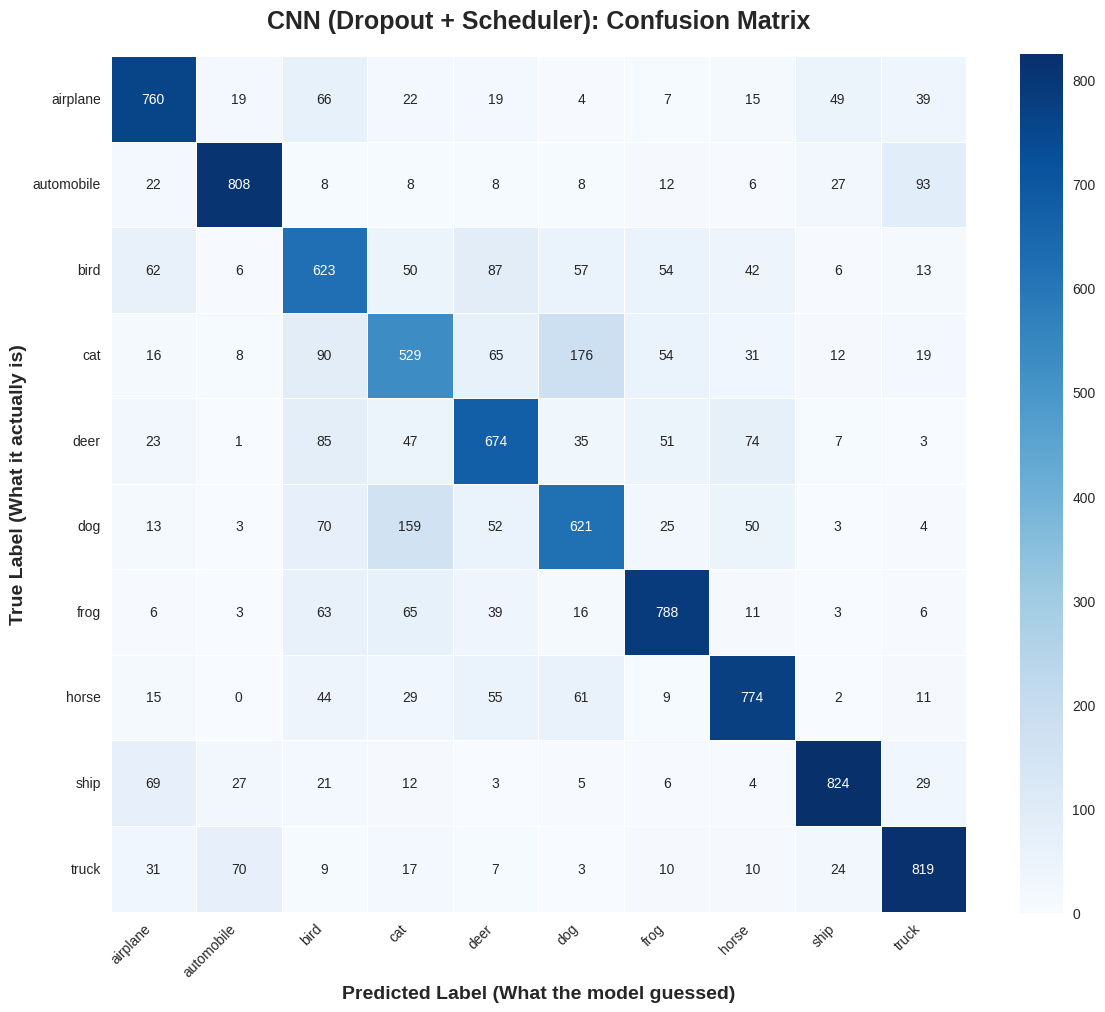

In [26]:
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# CIFAR-10 class names for labeling the matrix
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

def generate_full_report(model, dataloader):
    print("Gathering predictions for final report...")
    model.eval() # CRITICAL: Turn off Dropout!

    all_preds = []
    all_true = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            preds = torch.argmax(outputs, dim=1)

            # Move to CPU and convert to numpy for Scikit-Learn
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.numpy())

    # 2. Calculate Metrics
    acc = accuracy_score(all_true, all_preds)
    precision = precision_score(all_true, all_preds, average='macro')
    recall = recall_score(all_true, all_preds, average='macro')

    print("\n" + "="*40)
    print("FINAL MODEL PERFORMANCE REPORT")
    print("="*40)
    print(f"Accuracy:  {acc * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall:    {recall * 100:.2f}%")
    print("="*40)

    # 3. Generate Confusion Matrix
    cm = confusion_matrix(all_true, all_preds)

    # 4. Plotting the Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cifar10_classes,
                yticklabels=cifar10_classes,
                linewidths=.5, square=True)

    plt.title('CNN (Dropout + Scheduler): Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label (What it actually is)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label (What the model guessed)', fontsize=14, fontweight='bold')

    # Rotate x-axis labels so they don't overlap
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

# Run the report on your trained model
generate_full_report(cnn_dropout, eval_loader)

Up to this point having the warmup and exponential decay has been very helpful alongside increasing epochs to 25. I see from the graph that we were able to reach a lower loss than any of the previous models, with high accuracy. Now not "understandable" mistakes are not found as much. We still have the least performing labels are dogs, and cats, the model keeps mistakening them for the other. I believe in this case we can increase their examples in the dataset to enable the model to learn more. We could also increase the depth of the CNN in terms of number of layers to allow the model to catch more relations.